# Project 3: Supply Chain Analytics - Demand Forecasting & Anomaly Detection

## Week 1

### Member 2: Time-Series Processing & Decomposition

**Objective**
- Perform weekly and monthly resampling
- Handle missing dates using interpolation
- Apply time-series decomposition
- Analyze Trend, Seasonal and Residual components

## Step 1: Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose

import warnings
warnings.filterwarnings("ignore")

## Step 2: Load the Cleaned Dataset

In [2]:
df = pd.read_excel("clean_retail_storeinventory.xlsx")

df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


## Step 3: Verify Dataset Structure

In [3]:
print("Shape :", df.shape)

print("\nColumns")
print(df.columns)

df.info()

Shape : (73100, 15)

Columns
Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast',
       'Price', 'Discount', 'Weather Condition', 'Holiday/Promotion',
       'Competitor Pricing', 'Seasonality'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                73100 non-null  datetime64[ns]
 1   Store ID            73100 non-null  object        
 2   Product ID          73100 non-null  object        
 3   Category            73100 non-null  object        
 4   Region              73100 non-null  object        
 5   Inventory Level     73100 non-null  int64         
 6   Units Sold          73100 non-null  int64         
 7   Units Ordered       73100 non-null  int64         
 8   Demand Forecast     7

## Step 4: Set Date as Time-Series Index

In [4]:
df["Date"] = pd.to_datetime(df["Date"])

df.set_index("Date", inplace=True)

df.head()

,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
Date,,,,,,,,,,,,,,
2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


## Step 5: Weekly Time-Series Resampling

In this step, the daily supply chain data is resampled into weekly aggregates. Weekly resampling helps identify broader demand trends by reducing daily fluctuations.

In [5]:
df.select_dtypes(include='number').columns

Index(['Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast',
       'Price', 'Discount', 'Holiday/Promotion', 'Competitor Pricing'],
      dtype='object')

In [6]:
weekly_sales = df['Units Sold'].resample('W').sum()

weekly_sales.head()

Date
2022-01-02    27899
2022-01-09    94580
2022-01-16    95299
2022-01-23    95985
2022-01-30    92988
Freq: W-SUN, Name: Units Sold, dtype: int64

In [7]:
print("Weekly Data Shape :", weekly_sales.shape)

Weekly Data Shape : (106,)


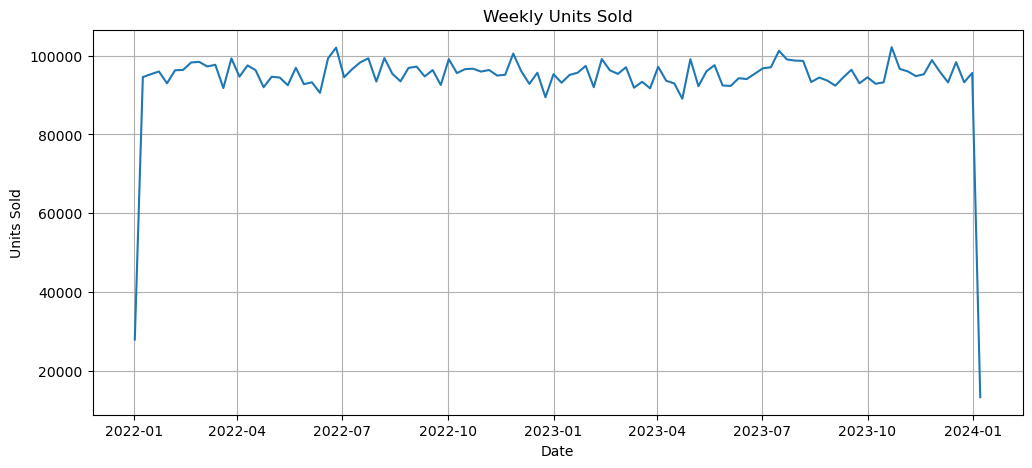

In [8]:
plt.figure(figsize=(12,5))

plt.plot(weekly_sales)

plt.title("Weekly Units Sold")

plt.xlabel("Date")

plt.ylabel("Units Sold")

plt.grid(True)

plt.show()

### Observation

The weekly resampling aggregates daily sales into weekly totals, making long-term sales trends easier to analyze while reducing daily fluctuations.

In [9]:
weekly_sales.to_excel("weekly_units_sold.xlsx")

print("Weekly sales exported successfully.")

Weekly sales exported successfully.
